
# **Problem Statement**

This project aims to predict the prices of common breakfast food items across different cities using economic and geographic data. Food prices are an important part of cost of living and inflation, so accurate predictions can help governments and people to observe whether there is a imminent need in investing in food sectors.

The prediction target is **Price_USD**, which represents the price of each individual food item. This is a **regression task** because the goal is to predict a continuous numerical value (price) given 6 months data.

To forecast prices, the project uses a machine learning approach that models item level prices based on features such as region, time, and economic indicators like inflation. Predicted item prices can then be used to estimate total food basket costs.



# Dataset Description
The dataset is fairly recent and taken from https://www.kaggle.com/datasets/waddahali/global-grocery-inflation-20252026 


 The dataset contains 14 different food prices from 122 cities throughout the world and kept track for 6 months from 2025 October to 2026 March. There exists 14 features and 10248 rows in the dataset. The dataset is fully complete without any null values however only having 6 months data for each item is a limitation for our algorithm.

 ### **Feature Descriptions**

* **City**: Name of the city where the price data was collected.

* **Country**: Country corresponding to the city.

* **ISO_Country_Code**: Standardized country code for identification.

* **Region**: Subdivision or geographical region within a country.

* **Continent**: Continent where the country is located.

* **Month**: Date representing the time period of the observation.

* **Month_Name**: Textual representation of the month.

* **Item**: Name of the food item (e.g., eggs, milk, bread).

* **Item_Key**: Unique identifier for each food item.

* **Item_Category**: Category grouping of items (e.g., dairy, grains).

* **Quantity**: Amount of the item measured.

* **Unit**: Unit of measurement (e.g., kg, liter).

* **Price_Local**: Price of the item in local currency.

* **Currency_Local**: Local currency used for pricing.

* **Price_USD**: Price of the item converted to USD (target variable).

* **Exchange_Rate**: Conversion rate from local currency to USD.

* **YoY_Inflation_Estimate_Pct**: Estimated year-over-year inflation rate.

* **Inflation_Source**: Source of the inflation data.

* **FAO_Index_Value**: Global food price index from FAO.

* **FAO_Index_Date**: Date of the FAO index value.

* **FAO_YoY_Change_Pct**: Year-over-year percentage change in FAO index.

* **USDA_All_Food_Forecast_Pct**: Forecasted change in overall food prices (USDA).

* **USDA_Food_At_Home_Pct**: Forecasted change in at-home food prices.

* **Data_Collection_Date**: Date when the data was collected.

* **Source_URL**: Source link for the data.

* **Population_Estimate**: Estimated population of the city or country.

* **Breakfast_Basket_USD**: Total cost of a predefined breakfast basket in USD.

 

# Data Loading and Initial Inspection

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("breakfast basket.csv")
df.head()

,City,Country,ISO_Country_Code,Region,Continent,Month,Month_Name,Item,Item_Key,Item_Category,...,Inflation_Source,FAO_Index_Value,FAO_Index_Date,FAO_YoY_Change_Pct,USDA_All_Food_Forecast_Pct,USDA_Food_At_Home_Pct,Data_Collection_Date,Source_URL,Population_Estimate,Breakfast_Basket_USD
0,New York,United States,USA,North America,North America,2025-10,October 2025,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,127.1,October 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.18
1,New York,United States,USA,North America,North America,2025-11,November 2025,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,126.2,November 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.40
2,New York,United States,USA,North America,North America,2025-12,December 2025,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,125.8,December 2025,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,17.02
3,New York,United States,USA,North America,North America,2026-01,January 2026,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,124.2,January 2026,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.80
4,New York,United States,USA,North America,North America,2026-02,February 2026,Milk (1 Liter),Milk_1L,Dairy,...,USDA Food Price Outlook / IMF WEO 2026,125.3,February 2026,-1.0,3.1,2.5,2026-03-20,https://www.numbeo.com/food-prices/in/New-York,8336817,16.82


# Data Cleaning


In [152]:
df.info() # no data exists 6x14x122 = 10248 rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10248 entries, 0 to 10247
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   City                        10248 non-null  object 
 1   Country                     10248 non-null  object 
 2   ISO_Country_Code            10248 non-null  object 
 3   Region                      10248 non-null  object 
 4   Continent                   10248 non-null  object 
 5   Month                       10248 non-null  object 
 6   Month_Name                  10248 non-null  object 
 7   Item                        10248 non-null  object 
 8   Item_Key                    10248 non-null  object 
 9   Item_Category               10248 non-null  object 
 10  Quantity                    10248 non-null  float64
 11  Unit                        10248 non-null  object 
 12  Price_Local                 10248 non-null  float64
 13  Currency_Local              102

In [153]:
# Checking for duplicates
df.duplicated().sum() # no duplicate

0

In [154]:
# Removing redundant and irrelevant columns
df = df.drop(columns=[
    'ISO_Country_Code', # unnecessary    
    'Month_Name', #redundant         
    'Item_Key', #redundant with item           
    'Inflation_Source', # source unnecessary    
    'Data_Collection_Date', #redundant
    'Unit' , #same for all
    'Quantity', #same for all
    'Price_Local',# local price and currency is unnecessary and can still be calculated by other features
    'Currency_Local', 
    'FAO_Index_Date',
    'Source_URL' #not needed          
])
# finding constant valued columns and keeping the value
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]


print("Constant columns:")
print(constant_cols)


Constant columns:
['FAO_YoY_Change_Pct', 'USDA_All_Food_Forecast_Pct', 'USDA_Food_At_Home_Pct']


In [155]:
# Dropping constant columns
FAO_YoY_Change = -1.0
USDA_All_Food = 3.1
USDA_At_Home = 2.5
df = df.drop(columns=constant_cols)
df.head()

,City,Country,Region,Continent,Month,Item,Item_Category,Price_USD,Exchange_Rate,YoY_Inflation_Estimate_Pct,FAO_Index_Value,Population_Estimate,Breakfast_Basket_USD
0,New York,United States,North America,North America,2025-10,Milk (1 Liter),Dairy,1.32,1.0,4.3,127.1,8336817,16.18
1,New York,United States,North America,North America,2025-11,Milk (1 Liter),Dairy,1.33,1.0,4.3,126.2,8336817,16.40
2,New York,United States,North America,North America,2025-12,Milk (1 Liter),Dairy,1.34,1.0,4.3,125.8,8336817,17.02
3,New York,United States,North America,North America,2026-01,Milk (1 Liter),Dairy,1.30,1.0,4.3,124.2,8336817,16.80
4,New York,United States,North America,North America,2026-02,Milk (1 Liter),Dairy,1.35,1.0,4.3,125.3,8336817,16.82


In [156]:
# Changing to more usable dtypes
#to datetime
df['Month'] = pd.to_datetime(df['Month'])

#to category
cat_cols = ['City', 'Country', 'Continent', 'Item']

for col in cat_cols:
    df[col] = df[col].astype('category')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10248 entries, 0 to 10247
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   City                        10248 non-null  category      
 1   Country                     10248 non-null  category      
 2   Region                      10248 non-null  object        
 3   Continent                   10248 non-null  category      
 4   Month                       10248 non-null  datetime64[ns]
 5   Item                        10248 non-null  category      
 6   Item_Category               10248 non-null  object        
 7   Price_USD                   10248 non-null  float64       
 8   Exchange_Rate               10248 non-null  float64       
 9   YoY_Inflation_Estimate_Pct  10248 non-null  float64       
 10  FAO_Index_Value             10248 non-null  float64       
 11  Population_Estimate         10248 non-null  int64     

In [157]:
# Detecting outliers - IQR score does not work as it is because some items are way more expensive 
# than others also prices vary with region a lot instead I made an outlier for each country and item
df['price_ratio'] = df['Price_USD'] / df.groupby(['Item', 'Country'])['Price_USD'].transform('median')

outliers = df[(df['price_ratio'] < 0.5) | (df['price_ratio'] > 1.5)]
outliers.isnull()
df = df.drop(columns=['price_ratio'])

C:\Users\ab165988\AppData\Local\Temp\ipykernel_8012\3218449538.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['price_ratio'] = df['Price_USD'] / df.groupby(['Item', 'Country'])['Price_USD'].transform('median')


In [158]:
# Inconsistent categories 
df['City'] = df['City'].str.strip().str.title()
df['Country'] = df['Country'].str.strip().str.title()
df['Item'] = df['Item'].str.strip().str.lower()
# checking whether a country or city's name is written inconsistently
city_counts = df['City'].value_counts()
bad_cities = city_counts[city_counts != 84]

country_counts = df['Country'].value_counts()
bad_countries = country_counts[country_counts < 80]

region_counts = df['Region'].value_counts()
bad_regions = region_counts[region_counts < 80]

print(bad_regions) 
print(bad_countries)
print(bad_cities) # Categories are consistent


Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)


# Univariate Analysis


--- Price_USD ---
Mean: 4.479190085870414
Median: 2.42
Std: 5.372603366570921
Skewness: 2.9097187326435736


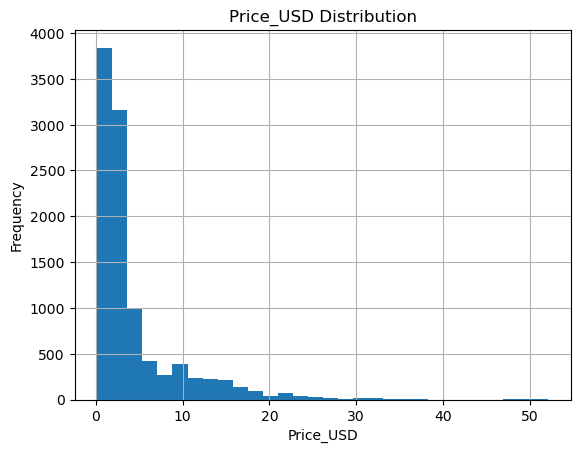


--- Exchange_Rate ---
Mean: 0.486773012295082
Median: 0.196
Std: 0.5975308655894936
Skewness: 1.6643729341943845


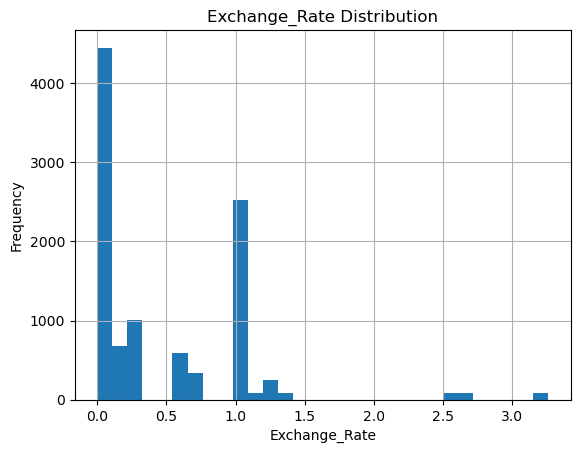


--- YoY_Inflation_Estimate_Pct ---
Mean: 5.527049180327869
Median: 5.5
Std: 2.4868413721955105
Skewness: 0.7509981451396571


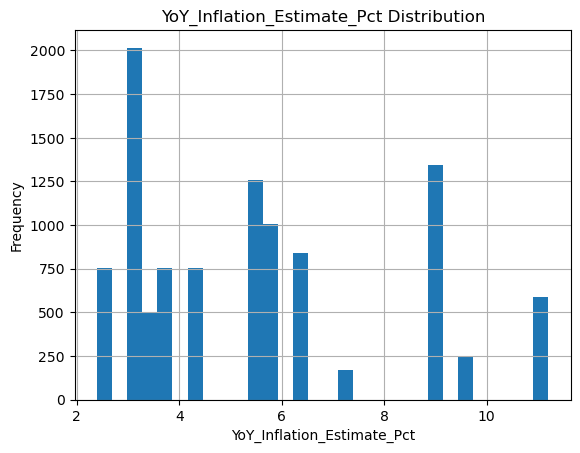


--- FAO_Index_Value ---
Mean: 125.76666666666665
Median: 125.9
Std: 0.8844764320928846
Skewness: -0.35718690355249577


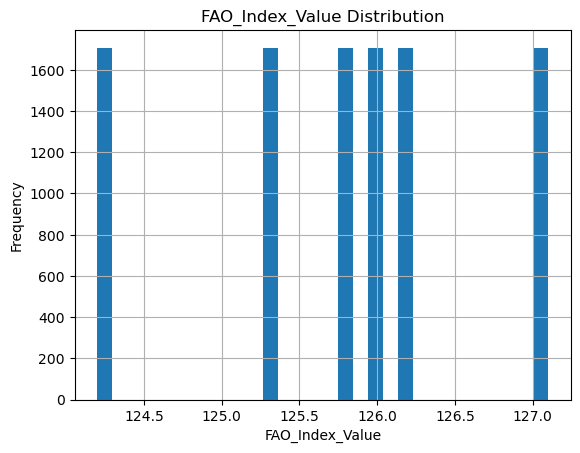


--- Population_Estimate ---
Mean: 4562348.360655738
Median: 2564853.5
Std: 5005719.339235295
Skewness: 1.9228530493630593


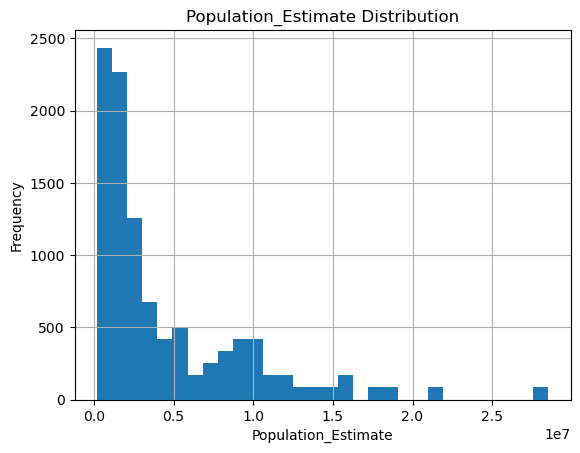


--- Breakfast_Basket_USD ---
Mean: 9.563032786885245
Median: 9.165
Std: 3.982560202393149
Skewness: 0.5251738026493256


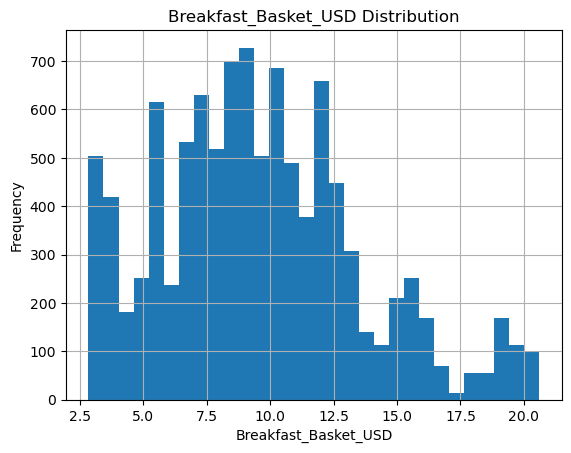

In [159]:
# Numerical analysis
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in num_cols:
    print(f"\n--- {col} ---")
    
    # Stats
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Std:", df[col].std())
    print("Skewness:", df[col].skew())
    
    # Histogram
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Some graphs above may not mean much as it shows all features their frequency and its maximum minimum values, and apparently very irrelevant, these graphs simply exist.

# Categorical Analysis

The graphs below shows top city, country, region data. As it stands we have multiple cities from america and some highly populated asian countries we might expect to get better predictions for these countries as we have much larger data on them. Other than that these graphs are very useless for our model.


--- City ---
Top categories:
City
New York     84
Manila       84
Jakarta      84
Singapore    84
Bangkok      84
Taipei       84
Hong Kong    84
Shenzhen     84
Guangzhou    84
Shanghai     84
Name: count, dtype: int64


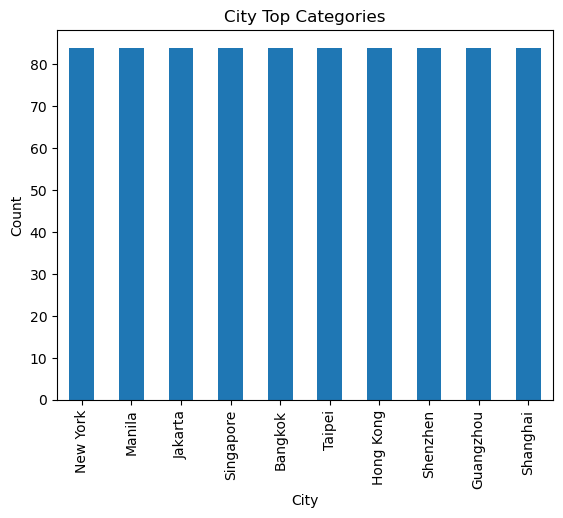


--- Country ---
Top categories:
Country
United States     504
India             420
Australia         336
China             336
United Kingdom    252
Germany           252
Canada            252
Italy             252
Pakistan          168
Saudi Arabia      168
Name: count, dtype: int64


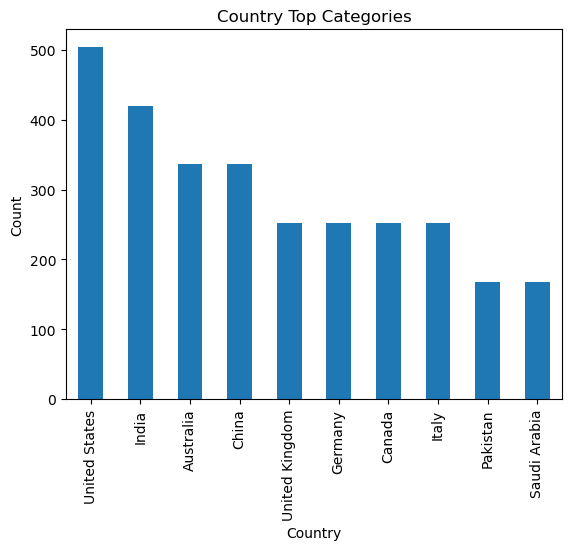


--- Region ---
Top categories:
Region
Western Europe        2016
MENA                  1344
Eastern Europe        1260
Latin America         1008
South Asia             840
North America          756
East Asia              756
Southeast Asia         756
Sub-Saharan Africa     588
Oceania                504
Name: count, dtype: int64


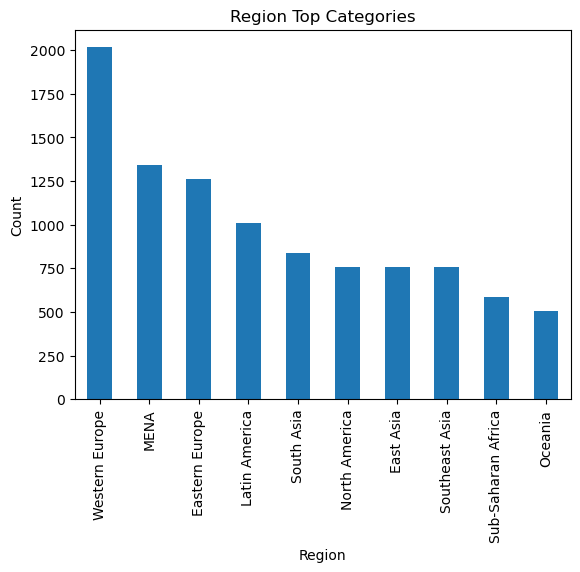


--- Continent ---
Top categories:
Continent
Asia             3612
Europe           3444
North America    1008
Africa            924
South America     756
Oceania           504
Name: count, dtype: int64


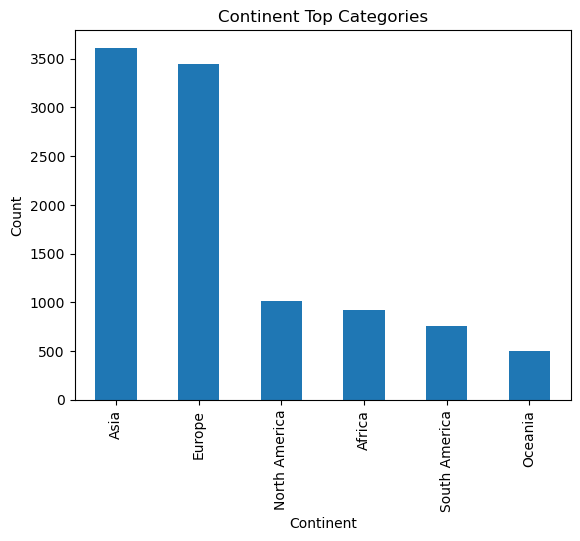


--- Item ---
Top categories:
Item
milk (1 liter)              732
fresh white bread (500g)    732
white rice (1 kg)           732
eggs (regular, 12)          732
local cheese (1 kg)         732
chicken fillets (1 kg)      732
beef round (1 kg)           732
apples (1 kg)               732
bananas (1 kg)              732
oranges (1 kg)              732
Name: count, dtype: int64


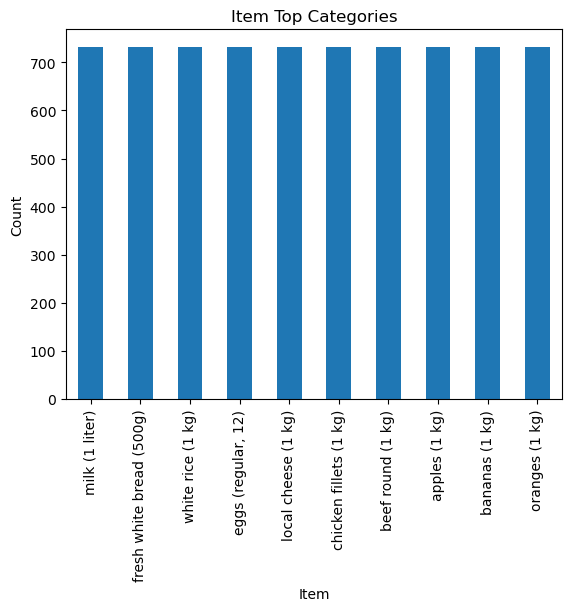


--- Item_Category ---
Top categories:
Item_Category
Vegetables      2928
Fruits          2196
Dairy           1464
Meat            1464
Bakery           732
Grains           732
Dairy & Eggs     732
Name: count, dtype: int64


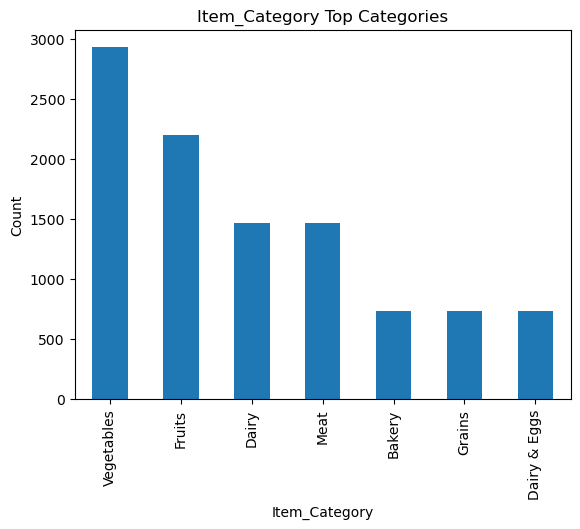

In [160]:
# Categorical analysis
for col in cat_cols:
    print(f"\n--- {col} ---")
    
    counts = df[col].value_counts()
    
    print("Top categories:")
    print(counts.head(10))
    
    # Bar chart (top 10 only to keep it readable)
    plt.figure()
    counts.head(10).plot(kind='bar')
    plt.title(f"{col} Top Categories")
    plt.ylabel("Count")
    plt.show()

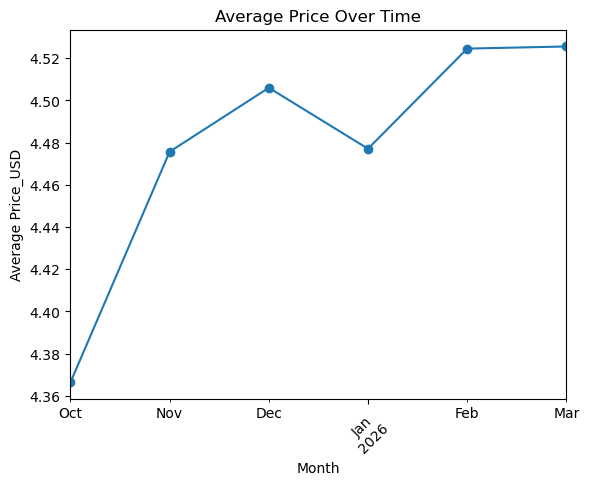

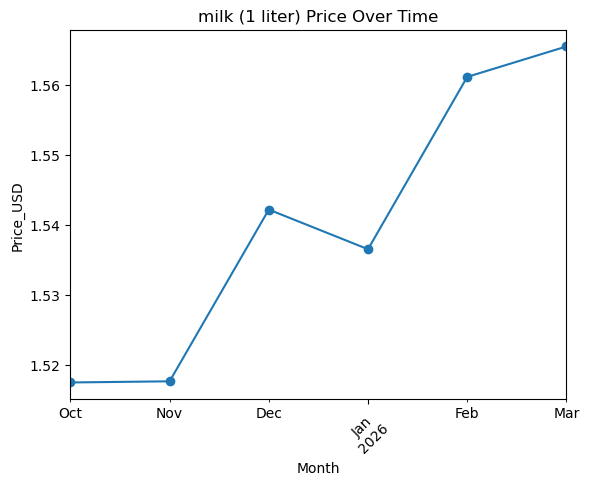

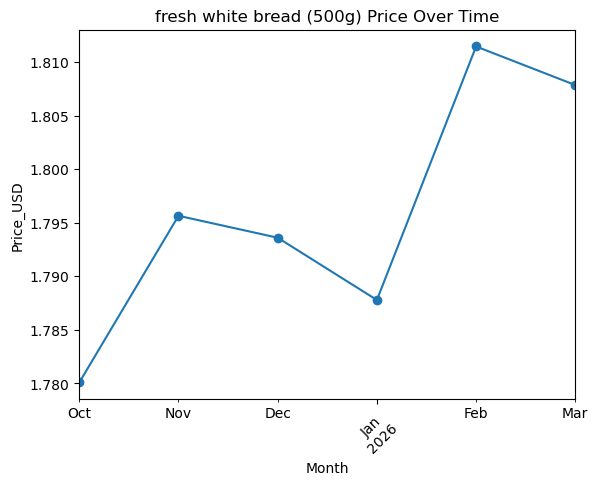

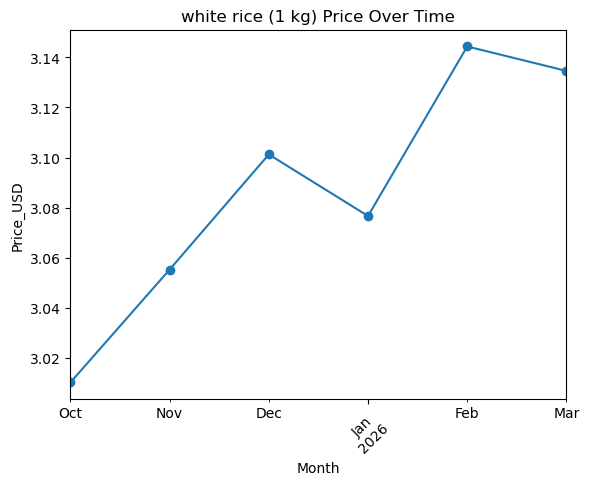

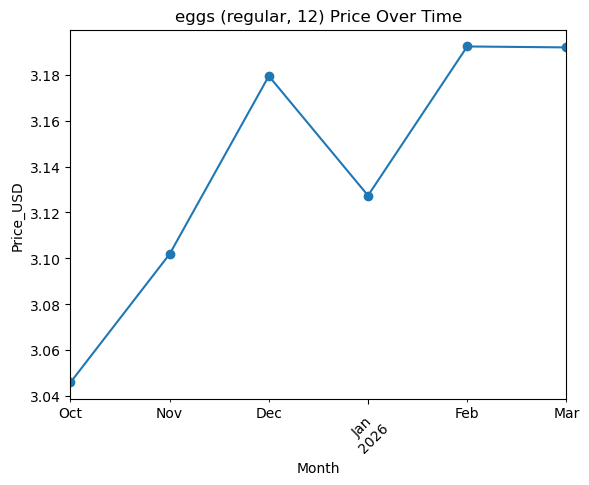

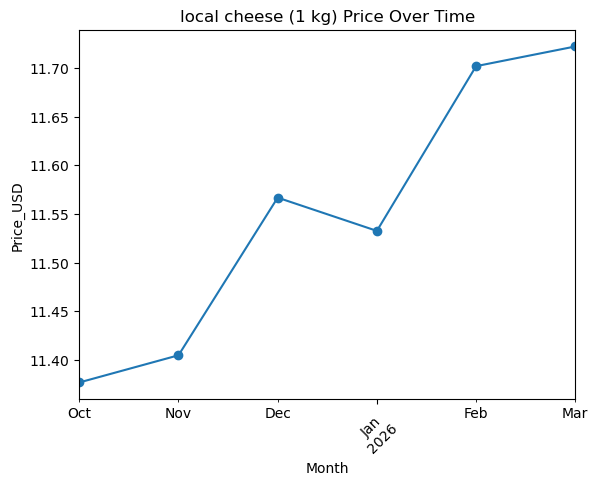

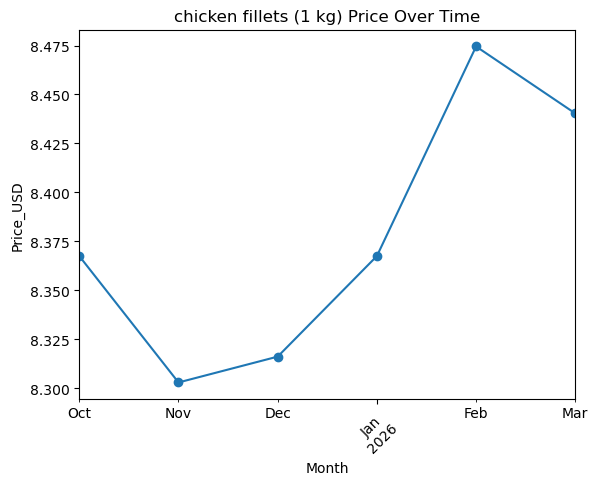

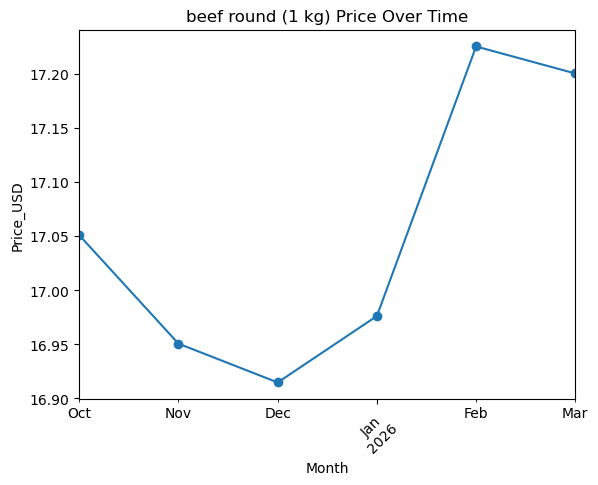

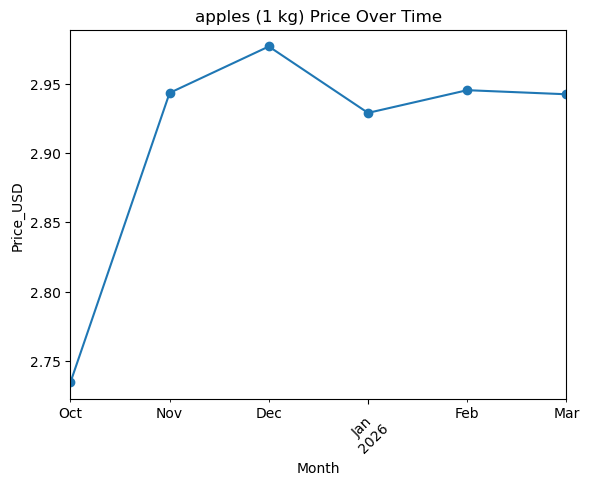

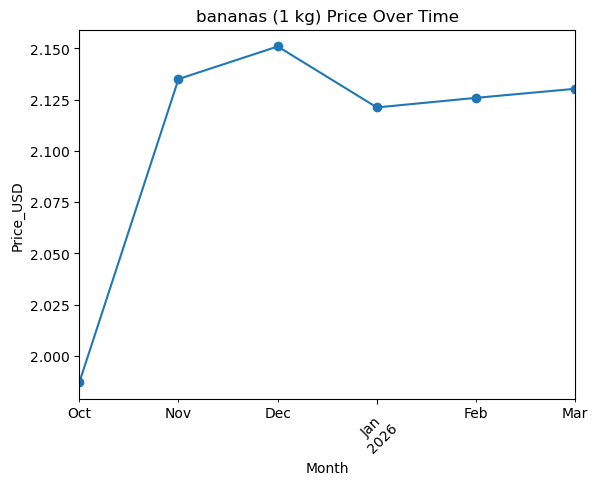

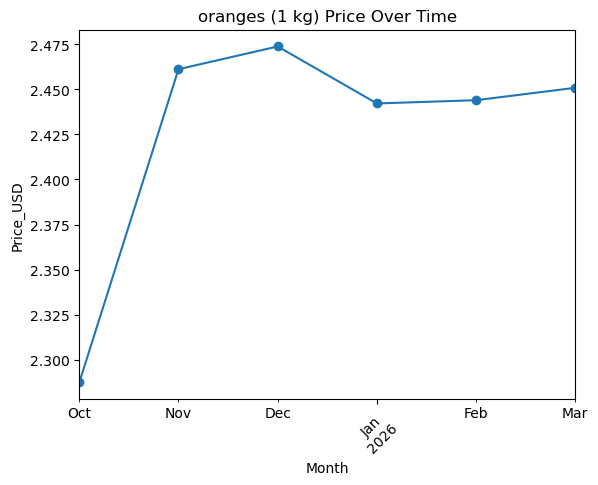

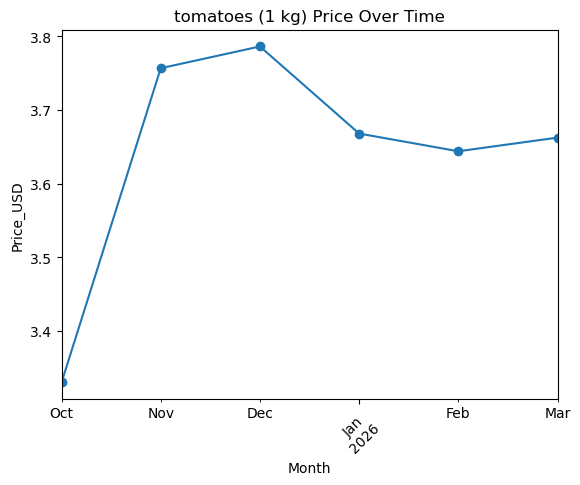

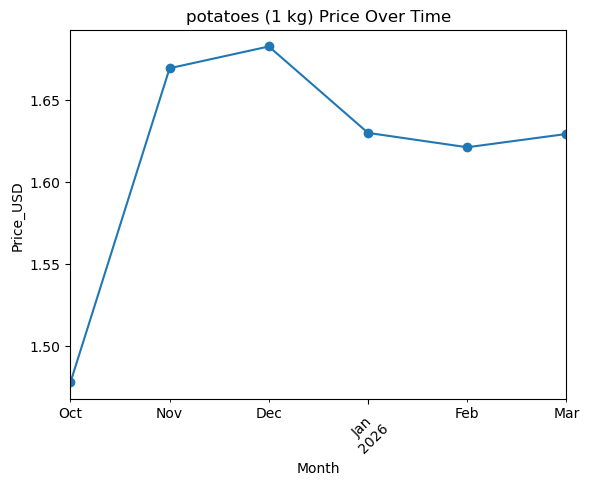

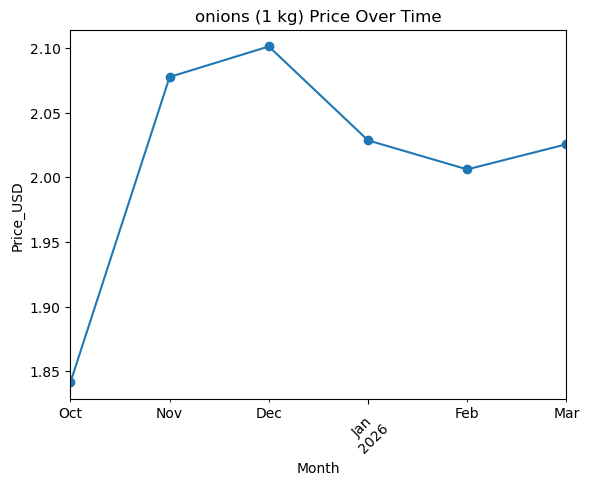

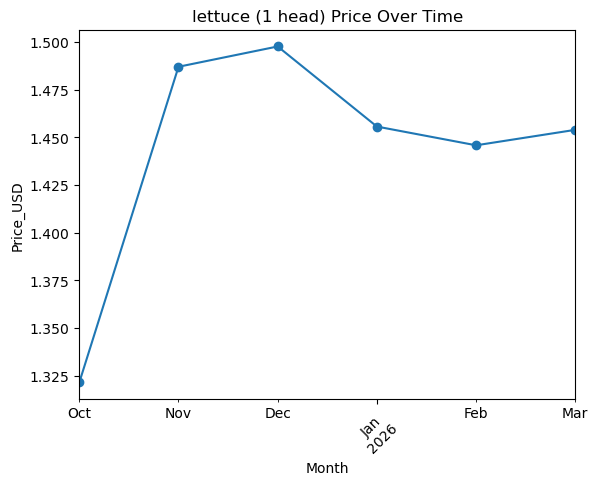

In [161]:
# Target variable analysis (USD_price)
import matplotlib.pyplot as plt

# Global average item price per month
monthly_avg = df.groupby('Month')['Price_USD'].mean()

plt.figure()
monthly_avg.plot(marker='o')
plt.title("Average Price Over Time")
plt.xlabel("Month")
plt.ylabel("Average Price_USD")
plt.xticks(rotation=45)
plt.show()
items = df['Item'].unique()
# Per item
for item in items:
    subset = df[df['Item'] == item]
    monthly = subset.groupby('Month')['Price_USD'].mean()
    
    plt.figure()
    monthly.plot(marker='o')
    plt.title(f"{item} Price Over Time")
    plt.xlabel("Month")
    plt.ylabel("Price_USD")
    plt.xticks(rotation=45)
    plt.show()

Vegetable and fruit prices follow the trend of dramatically increasing right after october as it is the middle of fall and many foods dont grow naturally. On the other hand beef and chicken meat prices show a gradual decrease, a contradictory situation with vegetables. Other animal based foods also show less dramatic increase than fruits and vegetables, many seasonal factors may influence this situation like weather, transportation etc. Hopefully our regression model can spot these differences in food types.

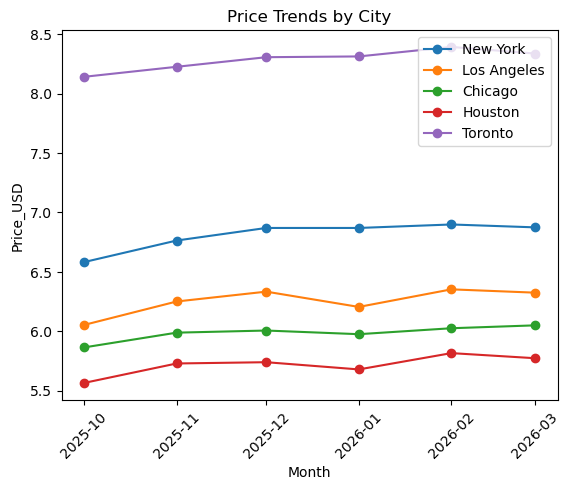

Continent
Africa           3.124459
South America    3.437024
Asia             4.025260
Europe           4.841733
Oceania          5.829940
North America    6.215169
Name: Price_USD, dtype: float64


C:\Users\ab165988\AppData\Local\Temp\ipykernel_8012\272658308.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  continent_avg = df.groupby('Continent')['Price_USD'].mean().sort_values()


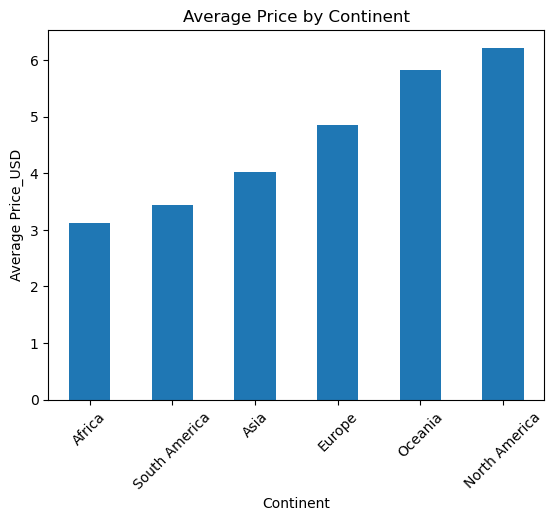

Region
South Asia            1.961143
North Africa          2.530833
Central Asia          2.982083
Sub-Saharan Africa    3.516259
Latin America         3.615218
Southeast Asia        3.749484
MENA                  3.751786
Eastern Europe        3.797079
Western Europe        5.654921
Oceania               5.829940
East Asia             6.859577
North America         6.903624
Name: Price_USD, dtype: float64


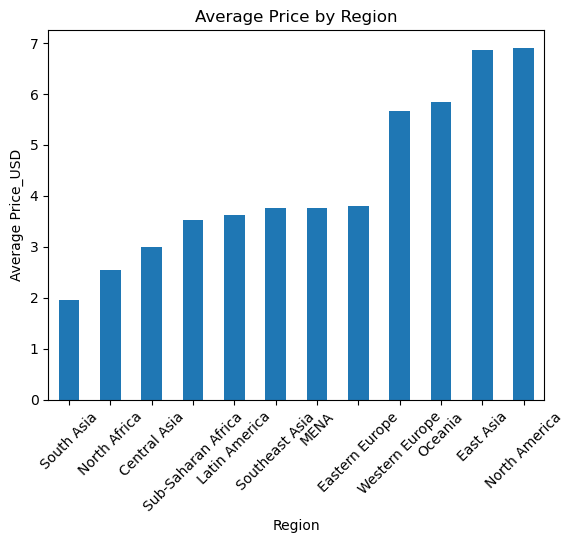

In [162]:
# Target variable analysis continued (USD_price)
cities = df['City'].unique()[:5]  # limit to 5 for readability

for city in cities:
    subset = df[df['City'] == city]
    monthly = subset.groupby('Month')['Price_USD'].mean()
    
    plt.plot(monthly.index, monthly.values, marker='o', label=city)

plt.legend()
plt.title("Price Trends by City")
plt.xlabel("Month")
plt.ylabel("Price_USD")
plt.xticks(rotation=45)
plt.show()
import matplotlib.pyplot as plt

continent_avg = df.groupby('Continent')['Price_USD'].mean().sort_values()

print(continent_avg)

continent_avg.plot(kind='bar')
plt.title("Average Price by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Price_USD")
plt.xticks(rotation=45)
plt.show()
import matplotlib.pyplot as plt

region_avg = df.groupby('Region')['Price_USD'].mean().sort_values()

print(region_avg)

plt.figure()
region_avg.plot(kind='bar')
plt.title("Average Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price_USD")
plt.xticks(rotation=45)
plt.show()

# Bivariate & Multivariate Analysis

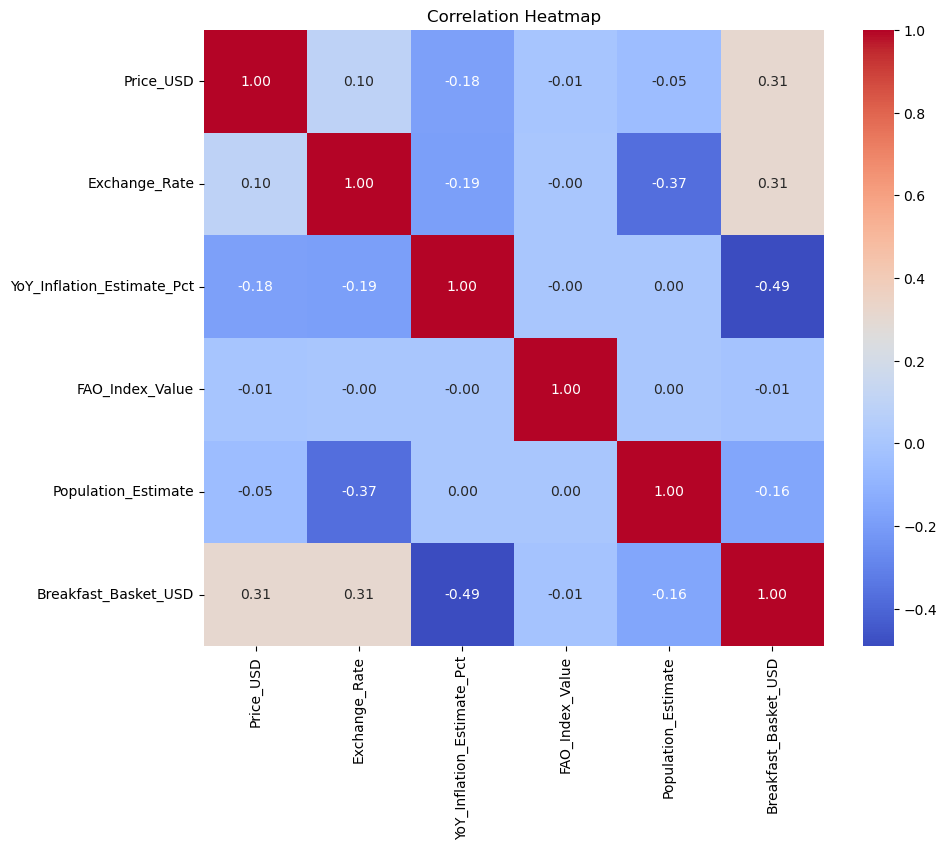

In [163]:
# Correlation heatmap
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

While year by year inflation values show somewhat strong relation with global food prices, this heatmap shows multiple factors affect the prices including not only these but geographical and ecomonical maybe even political factors. 
Populalation estimate shows exhange rate of crowded places are generally lower and total basket price is generally less and more ecomonic places to live (0.16 correlation).
FAO index value is very much irrelevant as it stands and total basket price is already a combination of individual items therefore there is not much to comment on these factors.

# Boxplots

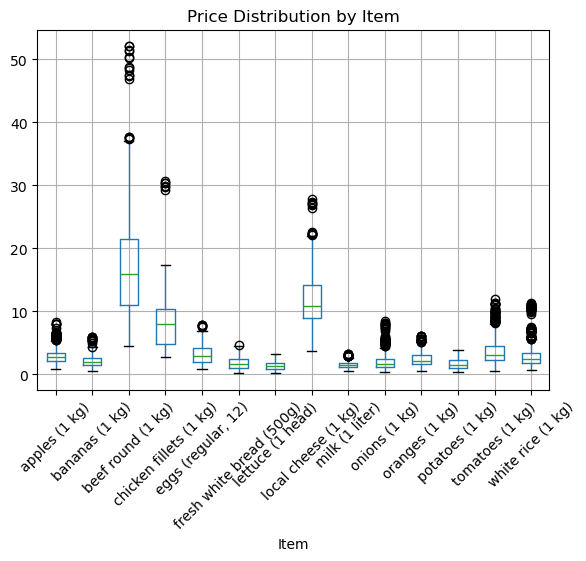

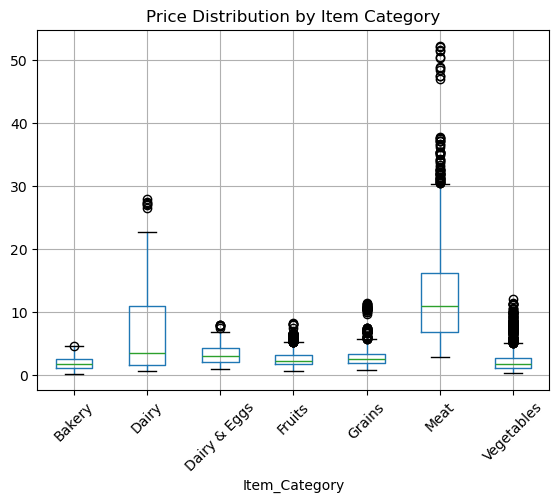

In [164]:
# Item vs Price
df.boxplot(column='Price_USD', by='Item')
plt.title("Price Distribution by Item")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()
# Item category vs price
df.boxplot(column='Price_USD', by='Item_Category')
plt.title("Price Distribution by Item Category")
plt.suptitle("")
plt.xticks(rotation=45)
plt.show()  



The boxplots show that food prices vary significantly across different items. Some items consistently have higher median prices and wider distributions, meaning that they are generally more expensive and show greater variability compared to others.

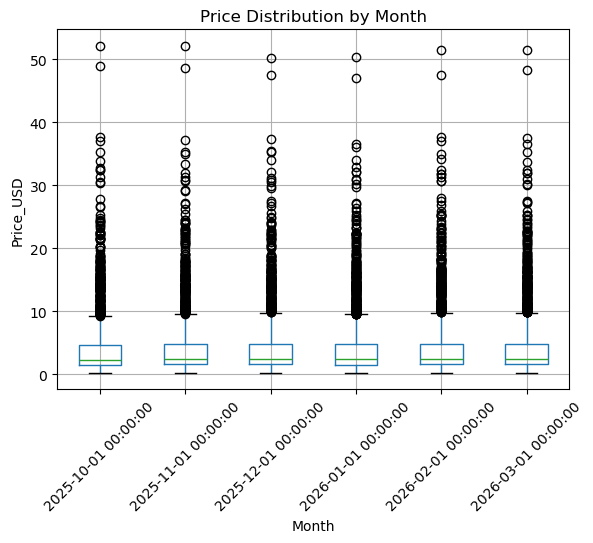

In [165]:
# price vs month
import matplotlib.pyplot as plt

df.boxplot(column='Price_USD', by='Month')

plt.title("Price Distribution by Month")
plt.suptitle("")  # removes extra default title
plt.xlabel("Month")
plt.ylabel("Price_USD")
plt.xticks(rotation=45)

plt.show()

Only slight shifts across months can be observed, these boxplots seem quite useless in showing the monthly changes in prices.

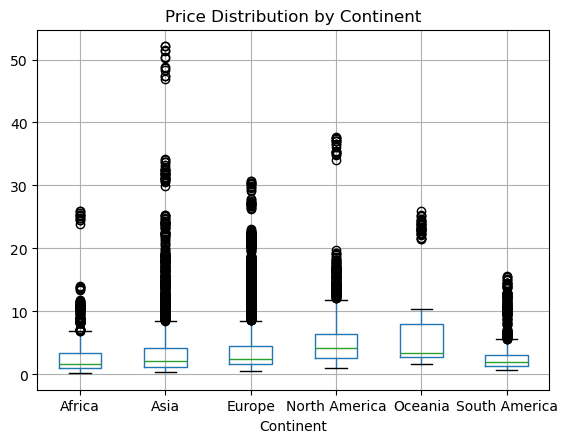

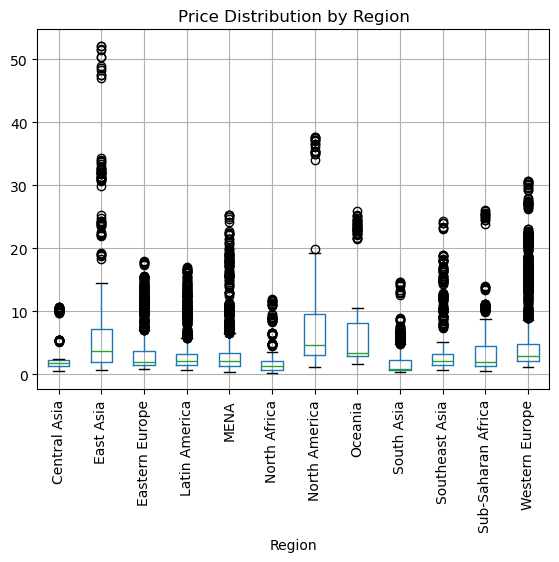

In [166]:
# Continent vs price
df.boxplot(column='Price_USD', by='Continent')
plt.title("Price Distribution by Continent")
plt.suptitle("")
plt.show()
# Region vs price
df.boxplot(column='Price_USD', by='Region')
plt.title("Price Distribution by Region")
plt.suptitle("")
plt.xticks(rotation=90)
plt.show()

We can observe especially east asia has pretty big variations between different countries. Also north america has high variations between different countries or states, both showing very imbalanced economies in same geographies. Such regional differences will increase the learning ability of our algorithms.

# Key Observations and Next Steps:

Food prices change most strongly by item, with some items consistently more expensive and more varying than others.
Geographic factors (region and continent) also influence prices, showing differences in cost of living and economic conditions.
Time effects are present, showing big distinctions for different item categories like vegetable and meat.
Inflation showed the highest correlation with prices in our heatmap however it was not as big as we liked it, probably because a 6 month data was not informative on the general trend enough or inflation values are not very realistic to the public.

The most predictive features appear to be Item, Region/Continent, and selected economic indicators, as they show clear differences in price distributions and trends.

Remaining data quality issues include low variability in some macroeconomic features, potential imbalance across regions, and limited time coverage, which may affect the model’s ability to capture long-term trends.
The current plan is to do forecast the next months prices given the preceding months prices with ML algorithms. Even though many plots showed zero relevancy to our case, our main focus will remain on item prices and whether we can catch a trend by looking at the previous months prices and  regional and economic differences, thus I believe our data will be sufficient.